In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"sklearn:  {__import__('sklearn').__version__}")

pandas:   3.0.1
numpy:    2.4.3
sklearn:  1.8.0


In [2]:
# Load WoE-encoded train and test sets

df_train = pd.read_pickle("../data/processed/df_train_woe.pkl")
df_test  = pd.read_pickle("../data/processed/df_test_woe.pkl")

print(f"{'Dataset':<12} {'Rows':>10} {'Columns':>10} {'Default Rate':>14}")
print("─" * 50)
for name, d in [("df_train", df_train), ("df_test", df_test)]:
    print(f"{name:<12} {len(d):>10,} {d.shape[1]:>10} "
          f"{d['default_flag'].mean()*100:>13.2f}%")

print()
print("Features:")
feature_cols = [c for c in df_train.columns if c != "default_flag"]
for c in feature_cols:
    print(f"  {c}")

Dataset            Rows    Columns   Default Rate
──────────────────────────────────────────────────
df_train        829,355         15         18.46%
df_test         518,744         15         22.42%

Features:
  woe_loan_amnt
  woe_installment
  woe_dti
  woe_fico_range_low
  woe_inq_last_6mths
  woe_revol_util
  woe_mort_acc
  woe_mths_since_recent_inq
  woe_log_annual_inc
  woe_sub_grade
  woe_term
  woe_purpose
  woe_verification_status
  woe_home_ownership


## Objective

Build a logistic regression PD (Probability of Default) model on
WoE-encoded features. Evaluate discrimination, calibration, and
business utility. Construct a credit scorecard from model coefficients.

### Why logistic regression?
- Industry standard for credit scorecards — interpretable, auditable,
  and directly maps to a points-based scorecard
- WoE encoding satisfies the linearity assumption by construction
- Coefficients are directly interpretable as log-odds contributions
- Regulators and risk teams expect to see logistic regression as the
  champion model in a credit risk setting

### Evaluation metrics
- AUROC and Gini coefficient — discrimination
- KS statistic — separation between default and non-default score distributions
- Calibration plot — are predicted probabilities accurate?
- Confusion matrix at 0.5 threshold — directional check only

In [3]:
# Prepare feature matrix and target vector

feature_cols = [c for c in df_train.columns if c != "default_flag"]
target       = "default_flag"

X_train = df_train[feature_cols].values
y_train = df_train[target].values

X_test  = df_test[feature_cols].values
y_test  = df_test[target].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}  default rate: {y_train.mean()*100:.2f}%")
print(f"y_test:  {y_test.shape}  default rate: {y_test.mean()*100:.2f}%")

X_train: (829355, 14)
X_test:  (518744, 14)
y_train: (829355,)  default rate: 18.46%
y_test:  (518744,)  default rate: 22.42%


In [4]:
# Fit logistic regression model
# WoE features are already in log-odds space — no scaling needed
# C=1e10 effectively removes regularisation — we want unregularised
# coefficients for scorecard interpretation

model = LogisticRegression(
    C             = 1e10,
    solver        = "lbfgs",
    max_iter      = 1000,
    random_state  = 42,
    class_weight  = None
)

model.fit(X_train, y_train)

print("Model fitted successfully")
print(f"Iterations:    {model.n_iter_[0]}")
print(f"Intercept:     {model.intercept_[0]:.4f}")
print()
print("Feature coefficients:")
print(f"{'Feature':<30} {'Coefficient':>12}")
print("─" * 45)
for feat, coef in sorted(
    zip(feature_cols, model.coef_[0]),
    key=lambda x: abs(x[1]), reverse=True
):
    print(f"{feat:<30} {coef:>12.4f}")

Model fitted successfully
Iterations:    13
Intercept:     -1.4857

Feature coefficients:
Feature                         Coefficient
─────────────────────────────────────────────
woe_log_annual_inc                   0.7103
woe_home_ownership                   0.6935
woe_mort_acc                         0.6326
woe_sub_grade                        0.6306
woe_term                             0.5968
woe_dti                              0.5264
woe_mths_since_recent_inq            0.4488
woe_fico_range_low                   0.4023
woe_installment                      0.3220
woe_revol_util                      -0.3157
woe_loan_amnt                        0.2370
woe_inq_last_6mths                   0.2204
woe_purpose                          0.2056
woe_verification_status              0.1610


In [5]:
# Check correlation between WoE features
# A negative coefficient in WoE logistic regression signals multicollinearity

corr_matrix = df_train[feature_cols].corr().round(3)

print("Correlations with woe_revol_util:")
print(corr_matrix["woe_revol_util"].sort_values())
print()
print("All feature-feature correlations above |0.3|:")
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.3:
            print(f"  {feature_cols[i]:<30} {feature_cols[j]:<30} {c:>8.3f}")

Correlations with woe_revol_util:
woe_inq_last_6mths          -0.0660
woe_mths_since_recent_inq   -0.0590
woe_log_annual_inc          -0.0550
woe_mort_acc                -0.0210
woe_purpose                 -0.0160
woe_home_ownership          -0.0110
woe_term                     0.0690
woe_verification_status      0.0780
woe_loan_amnt                0.1180
woe_installment              0.1220
woe_dti                      0.1730
woe_sub_grade                0.2820
woe_fico_range_low           0.4520
woe_revol_util               1.0000
Name: woe_revol_util, dtype: float64

All feature-feature correlations above |0.3|:
  woe_loan_amnt                  woe_installment                   0.808
  woe_loan_amnt                  woe_log_annual_inc               -0.399
  woe_loan_amnt                  woe_term                          0.419
  woe_fico_range_low             woe_revol_util                    0.452
  woe_fico_range_low             woe_sub_grade                     0.495
  woe_inq_las

In [6]:
# Drop correlated features causing sign flip
# woe_installment — corr 0.808 with woe_loan_amnt (keep loan_amnt, higher IV)
# woe_revol_util  — corr 0.452 with woe_fico_range_low (keep fico, higher IV)

drop_correlated = ["woe_installment", "woe_revol_util"]

feature_cols_v2 = [f for f in feature_cols if f not in drop_correlated]

X_train_v2 = df_train[feature_cols_v2].values
X_test_v2  = df_test[feature_cols_v2].values

print(f"Features after dropping correlated pair: {len(feature_cols_v2)}")
for f in feature_cols_v2:
    print(f"  {f}")

Features after dropping correlated pair: 12
  woe_loan_amnt
  woe_dti
  woe_fico_range_low
  woe_inq_last_6mths
  woe_mort_acc
  woe_mths_since_recent_inq
  woe_log_annual_inc
  woe_sub_grade
  woe_term
  woe_purpose
  woe_verification_status
  woe_home_ownership


In [7]:
# Refit logistic regression with 12 features

model_v2 = LogisticRegression(
    C            = 1e10,
    solver       = "lbfgs",
    max_iter     = 1000,
    random_state = 42,
    class_weight = None
)

model_v2.fit(X_train_v2, y_train)

print("Model v2 fitted successfully")
print(f"Iterations: {model_v2.n_iter_[0]}")
print(f"Intercept:  {model_v2.intercept_[0]:.4f}")
print()
print("Feature coefficients:")
print(f"{'Feature':<30} {'Coefficient':>12}")
print("─" * 55)
for feat, coef in sorted(
    zip(feature_cols_v2, model_v2.coef_[0]),
    key=lambda x: abs(x[1]), reverse=True
):
    print(f"{feat:<30} {coef:>12.4f}")

all_positive = all(c > 0 for c in model_v2.coef_[0])
print()
print(f"All coefficients positive: {all_positive}")

Model v2 fitted successfully
Iterations: 17
Intercept:  -1.4853

Feature coefficients:
Feature                         Coefficient
───────────────────────────────────────────────────────
woe_log_annual_inc                   0.7524
woe_home_ownership                   0.7025
woe_mort_acc                         0.6421
woe_sub_grade                        0.6207
woe_term                             0.5876
woe_dti                              0.5077
woe_mths_since_recent_inq            0.4803
woe_loan_amnt                        0.4778
woe_fico_range_low                   0.3600
woe_purpose                          0.2505
woe_inq_last_6mths                   0.2491
woe_verification_status              0.1496

All coefficients positive: True


In [8]:
# Model evaluation — train and test set : Computes AUROC, Gini, KS statistic for a fitted model.
    

def evaluate_model(model, X, y, label):
    probs = model.predict_proba(X)[:, 1]

    # AUROC and Gini
    auroc = roc_auc_score(y, probs)
    gini  = 2 * auroc - 1

    # KS statistic
    fpr, tpr, thresholds = roc_curve(y, probs)
    ks = (tpr - fpr).max()

    print(f"{label}")
    print(f"  AUROC: {auroc:.4f}")
    print(f"  Gini:  {gini:.4f}")
    print(f"  KS:    {ks:.4f}")
    print()

    return probs, auroc, gini, ks


print("=" * 40)
print("MODEL EVALUATION")
print("=" * 40)
print()

train_probs, train_auroc, train_gini, train_ks = evaluate_model(
    model_v2, X_train_v2, y_train, "Train set"
)
test_probs, test_auroc, test_gini, test_ks = evaluate_model(
    model_v2, X_test_v2, y_test, "Test set"
)

# Overfitting check
print(f"Gini drop (train → test): {(train_gini - test_gini):.4f}")
print(f"KS drop   (train → test): {(train_ks - test_ks):.4f}")

MODEL EVALUATION

Train set
  AUROC: 0.7143
  Gini:  0.4286
  KS:    0.3107

Test set
  AUROC: 0.7042
  Gini:  0.4084
  KS:    0.2946

Gini drop (train → test): 0.0202
KS drop   (train → test): 0.0161


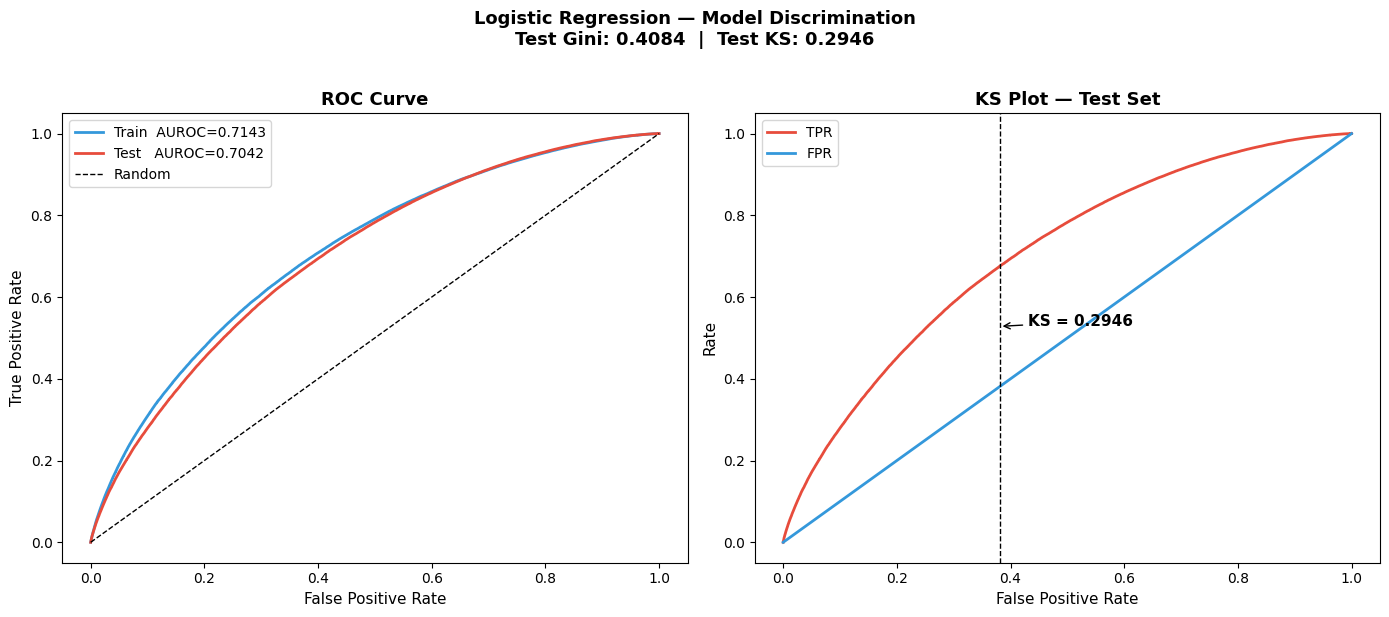

Saved: outputs/lr_roc_ks.png


In [9]:
# ROC curve and KS plot

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  test_probs)

axes[0].plot(fpr_train, tpr_train, color="#3498db", linewidth=2,
             label=f"Train  AUROC={train_auroc:.4f}")
axes[0].plot(fpr_test,  tpr_test,  color="#e74c3c", linewidth=2,
             label=f"Test   AUROC={test_auroc:.4f}")
axes[0].plot([0,1], [0,1], "k--", linewidth=1, label="Random")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

# KS plot — test set
fpr_ks, tpr_ks, _ = roc_curve(y_test, test_probs)
ks_idx = (tpr_ks - fpr_ks).argmax()

axes[1].plot(fpr_ks, tpr_ks, color="#e74c3c", linewidth=2, label="TPR")
axes[1].plot(fpr_ks, fpr_ks, color="#3498db", linewidth=2, label="FPR")
axes[1].axvline(x=fpr_ks[ks_idx], color="black", linestyle="--", linewidth=1)
axes[1].annotate(
    f"KS = {test_ks:.4f}",
    xy=(fpr_ks[ks_idx], (tpr_ks[ks_idx] + fpr_ks[ks_idx]) / 2),
    xytext=(fpr_ks[ks_idx] + 0.05, (tpr_ks[ks_idx] + fpr_ks[ks_idx]) / 2),
    fontsize=11, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black")
)
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("Rate", fontsize=11)
axes[1].set_title("KS Plot — Test Set", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)

plt.suptitle(
    "Logistic Regression — Model Discrimination\n"
    f"Test Gini: {test_gini:.4f}  |  Test KS: {test_ks:.4f}",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/lr_roc_ks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/lr_roc_ks.png")

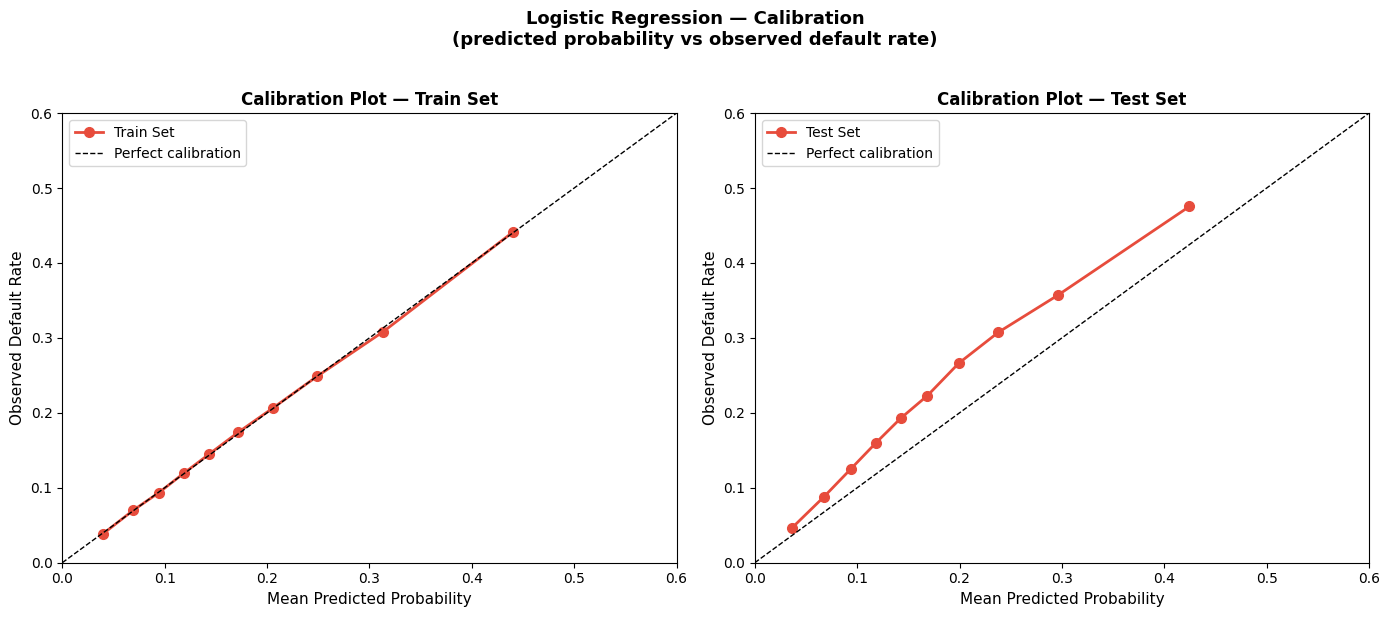

Saved: outputs/lr_calibration.png

Test set calibration table:
 mean_predicted  actual_rate  count
         0.0362       0.0462  51875
         0.0678       0.0882  51874
         0.0942       0.1257  51874
         0.1182       0.1598  51875
         0.1425       0.1927  51874
         0.1687       0.2231  51874
         0.1993       0.2663  51875
         0.2381       0.3076  51874
         0.2958       0.3568  51874
         0.4245       0.4754  51875


In [10]:
# Calibration plot — predicted probability vs actual default rate

def calibration_plot(y_true, y_prob, label, ax, n_bins=10):
    """
    Plots predicted probability vs observed default rate across deciles.
    A well-calibrated model should lie close to the diagonal.
    """
    df_cal = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df_cal["decile"] = pd.qcut(df_cal["y_prob"], q=n_bins, duplicates="drop")

    cal_summary = df_cal.groupby("decile").agg(
        mean_predicted = ("y_prob",  "mean"),
        actual_rate    = ("y_true",  "mean"),
        count          = ("y_true",  "count")
    ).reset_index()

    ax.plot(
        cal_summary["mean_predicted"],
        cal_summary["actual_rate"],
        marker="o", color="#e74c3c", linewidth=2, markersize=7,
        label=label
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax.set_ylabel("Observed Default Rate", fontsize=11)
    ax.set_title(f"Calibration Plot — {label}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.6)

    return cal_summary


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

train_cal = calibration_plot(y_train, train_probs, "Train Set", axes[0])
test_cal  = calibration_plot(y_test,  test_probs,  "Test Set",  axes[1])

plt.suptitle(
    "Logistic Regression — Calibration\n"
    "(predicted probability vs observed default rate)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/lr_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/lr_calibration.png")

print("\nTest set calibration table:")
print(test_cal[["mean_predicted", "actual_rate", "count"]].to_string(index=False))

In [11]:
import pickle

with open("../data/processed/woe_mappings.pkl", "rb") as f:
    woe_mappings = pickle.load(f)

with open("../data/processed/bin_edges.pkl", "rb") as f:
    bin_edges = pickle.load(f)

print(f"woe_mappings loaded: {len(woe_mappings)} features")
print(f"bin_edges loaded:    {len(bin_edges)} features")


woe_mappings loaded: 14 features
bin_edges loaded:    9 features


In [12]:
# Credit Scorecard Construction
# Standard scaling: 600 points = 50:1 odds (1 default per 50 non-defaults)
# PDO (Points to Double Odds) = 20

# Scorecard parameters
TARGET_SCORE = 600  # score at target odds
TARGET_ODDS  = 50   # odds at target score (good:bad)
PDO          = 20   # points to double the odds

# Derived scaling constants
factor = PDO / np.log(2)
offset = TARGET_SCORE - factor * np.log(TARGET_ODDS)

print(f"Scorecard scaling parameters:")
print(f"  Target score:  {TARGET_SCORE}")
print(f"  Target odds:   {TARGET_ODDS}:1")
print(f"  PDO:           {PDO}")
print(f"  Factor:        {factor:.4f}")
print(f"  Offset:        {offset:.4f}")
print()

# Convert coefficients to score points
# Score = Offset + Factor × (intercept + Σ βi × WoEi)
# Points for each bin = Factor × βi × WoEi

intercept = model_v2.intercept_[0]
coefs     = dict(zip(feature_cols_v2, model_v2.coef_[0]))

scorecard_rows = []

for feature in feature_cols_v2:
    orig_feature = feature.replace("woe_", "")
    beta         = coefs[feature]

    # Get WoE values for this feature from the mapping
    woe_map = woe_mappings[orig_feature]

    for bin_label, woe_val in woe_map.items():
        points = -round(factor * beta * woe_val)
        scorecard_rows.append({
            "feature"   : orig_feature,
            "bin"       : bin_label,
            "woe"       : round(woe_val, 4),
            "beta"      : round(beta, 4),
            "points"    : int(points)
        })

scorecard_df = pd.DataFrame(scorecard_rows)

# Base score from intercept
base_score = round(offset + factor * intercept)
print(f"Base score (intercept contribution): {base_score}")
print()

# Display scorecard by feature
for feature in feature_cols_v2:
    orig = feature.replace("woe_", "")
    subset = scorecard_df[scorecard_df["feature"] == orig].copy()
    subset = subset.sort_values("woe", ascending=False)
    print(f"\n{'─'*55}")
    print(f"  {orig.upper()}")
    print(f"{'─'*55}")
    print(f"  {'Bin':<35} {'WoE':>8} {'Points':>8}")
    for _, row in subset.iterrows():
        print(f"  {str(row['bin']):<35} {row['woe']:>8.4f} {row['points']:>8}")

Scorecard scaling parameters:
  Target score:  600
  Target odds:   50:1
  PDO:           20
  Factor:        28.8539
  Offset:        487.1229

Base score (intercept contribution): 444


───────────────────────────────────────────────────────
  LOAN_AMNT
───────────────────────────────────────────────────────
  Bin                                      WoE   Points
  (21000.0, 27000.0]                    0.1941       -3
  (15000.0, 18000.0]                    0.1874       -3
  (27000.0, 35000.0]                    0.1858       -3
  (18000.0, 21000.0]                    0.1475       -2
  (12000.0, 15000.0]                    0.0720       -1
  (10000.0, 12000.0]                    0.0622       -1
  (9000.0, 10000.0]                    -0.1148        2
  (7000.0, 9000.0]                     -0.2197        3
  (499.999, 5000.0]                    -0.2827        4
  (5000.0, 7000.0]                     -0.3102        4

───────────────────────────────────────────────────────
  DTI
─────────

Train scores — min: 377  max: 528  mean: 449.5
Test scores  — min: 378  max: 529  mean: 450.7


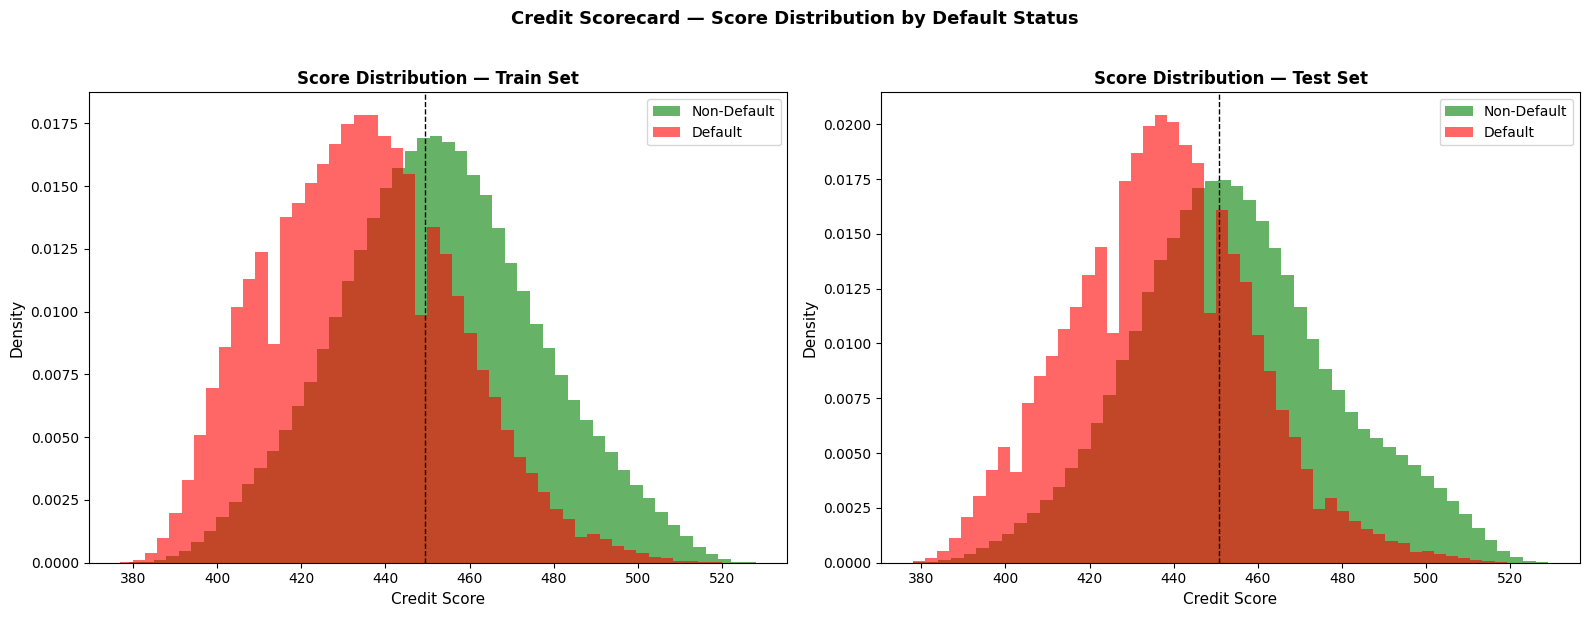

Saved: outputs/lr_score_distribution.png


In [13]:
# Apply scorecard to train and test sets
# Total score = base_score + sum of points for each feature bin

def apply_scorecard(df_woe, scorecard_df, base_score, feature_cols_v2):
    """
    Applies scorecard points to a WoE-encoded DataFrame.
    Returns array of credit scores.
    """
    scores = np.full(len(df_woe), base_score, dtype=float)

    for feature in feature_cols_v2:
        orig     = feature.replace("woe_", "")
        subset   = scorecard_df[scorecard_df["feature"] == orig]
        woe_to_pts = dict(zip(subset["woe"].round(4), subset["points"]))

        woe_vals = df_woe[feature].round(4)
        pts      = woe_vals.map(woe_to_pts).fillna(0)
        scores  += pts

    return scores.astype(int)


train_scores = apply_scorecard(
    df_train, scorecard_df, base_score, feature_cols_v2
)
test_scores  = apply_scorecard(
    df_test,  scorecard_df, base_score, feature_cols_v2
)

print(f"Train scores — min: {train_scores.min()}  "
      f"max: {train_scores.max()}  "
      f"mean: {train_scores.mean():.1f}")
print(f"Test scores  — min: {test_scores.min()}  "
      f"max: {test_scores.max()}  "
      f"mean: {test_scores.mean():.1f}")

# Score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, scores, y, label, color in [
    (axes[0], train_scores, y_train, "Train Set", "#3498db"),
    (axes[1], test_scores,  y_test,  "Test Set",  "#e74c3c"),
]:
    ax.hist(scores[y == 0], bins=50, alpha=0.6,
            color="green", label="Non-Default", density=True)
    ax.hist(scores[y == 1], bins=50, alpha=0.6,
            color="red",   label="Default",     density=True)
    ax.set_xlabel("Credit Score", fontsize=11)
    ax.set_ylabel("Density",      fontsize=11)
    ax.set_title(f"Score Distribution — {label}",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.axvline(x=np.mean(scores), color="black",
               linestyle="--", linewidth=1, label="Mean")

plt.suptitle(
    "Credit Scorecard — Score Distribution by Default Status",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/lr_score_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/lr_score_distribution.png")

In [14]:
# Decile analysis — default rate and cumulative capture by score decile

def decile_analysis(scores, y_true, label):
    df_dec = pd.DataFrame({"score": scores, "default": y_true})
    df_dec["decile"] = pd.qcut(
        df_dec["score"], q=10, labels=False, duplicates="drop"
    )
    # Decile 10 = highest score = lowest risk
    df_dec["decile"] = 10 - df_dec["decile"]

    summary = df_dec.groupby("decile").agg(
        count        = ("default", "count"),
        defaults     = ("default", "sum"),
        min_score    = ("score",   "min"),
        max_score    = ("score",   "max"),
    ).reset_index()

    summary["default_rate"]   = (summary["defaults"] / summary["count"] * 100).round(2)
    summary["cum_defaults"]   = summary["defaults"].cumsum()
    summary["cum_capture"]    = (summary["cum_defaults"] /
                                  summary["defaults"].sum() * 100).round(2)

    print(f"\n{label} — Decile Analysis")
    print(f"{'Decile':>7} {'Score Range':>14} {'Count':>8} "
          f"{'Defaults':>10} {'Default%':>10} {'Cum Capture%':>14}")
    print("─" * 70)
    for _, row in summary.iterrows():
        print(f"{int(row['decile']):>7} "
              f"{int(row['min_score']):>6}-{int(row['max_score']):<6} "
              f"{int(row['count']):>8,} "
              f"{int(row['defaults']):>10,} "
              f"{row['default_rate']:>10.2f}% "
              f"{row['cum_capture']:>13.2f}%")
    return summary

train_deciles = decile_analysis(train_scores, y_train, "Train Set")
test_deciles  = decile_analysis(test_scores,  y_test,  "Test Set")


Train Set — Decile Analysis
 Decile    Score Range    Count   Defaults   Default%   Cum Capture%
──────────────────────────────────────────────────────────────────────
      1    483-528      82,042      3,124       3.81%          2.04%
      2    471-482      81,792      5,695       6.96%          5.76%
      3    463-470      80,269      7,531       9.38%         10.68%
      4    456-462      85,466     10,048      11.76%         17.25%
      5    450-455      79,638     11,466      14.40%         24.74%
      6    444-449      80,211     13,771      17.17%         33.73%
      7    437-443      87,532     17,810      20.35%         45.37%
      8    429-436      84,684     21,038      24.84%         59.11%
      9    418-428      82,341     25,159      30.55%         75.55%
     10    377-417      85,380     37,423      43.83%        100.00%

Test Set — Decile Analysis
 Decile    Score Range    Count   Defaults   Default%   Cum Capture%
────────────────────────────────────────────

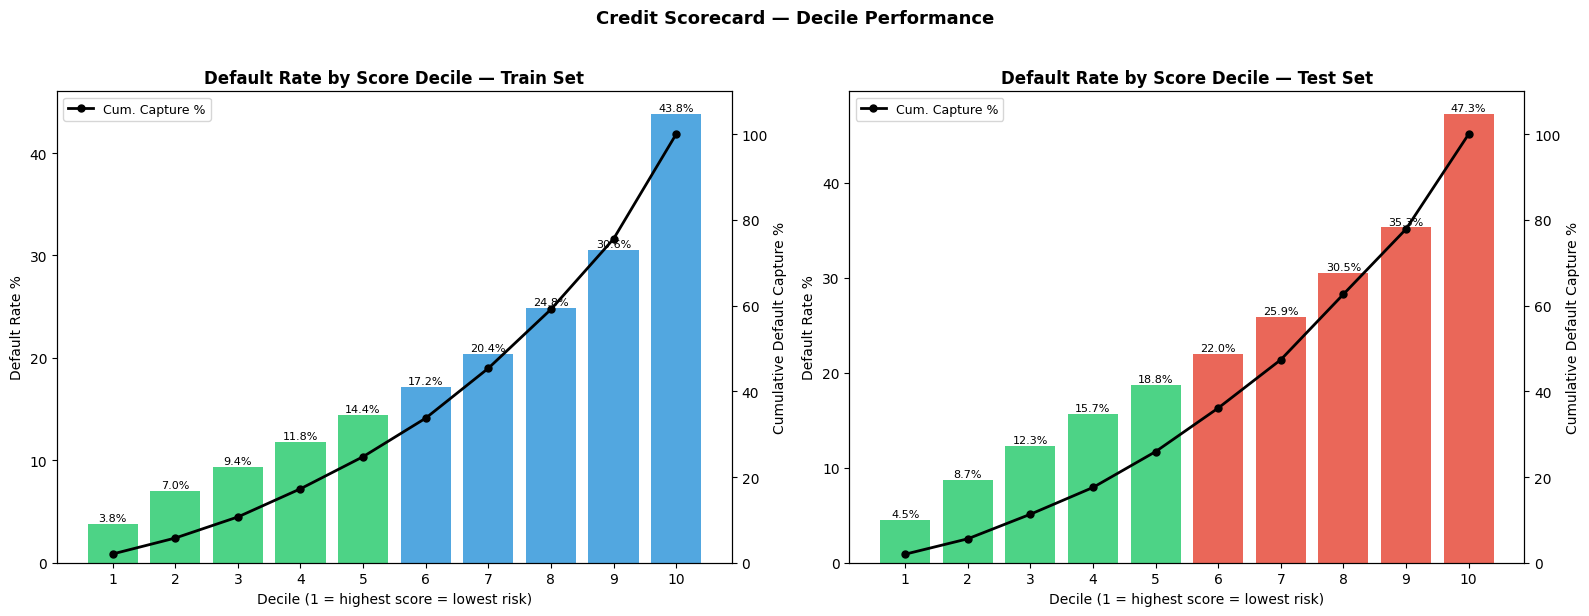

Saved: outputs/lr_decile_analysis.png


In [15]:
# Decile default rate chart

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, deciles, label, color in [
    (axes[0], train_deciles, "Train Set", "#3498db"),
    (axes[1], test_deciles,  "Test Set",  "#e74c3c"),
]:
    bars = ax.bar(
        deciles["decile"],
        deciles["default_rate"],
        color=[color if d > 5 else "#2ecc71" for d in deciles["decile"]],
        alpha=0.85
    )
    ax2 = ax.twinx()
    ax2.plot(
        deciles["decile"],
        deciles["cum_capture"],
        color="black", marker="o", linewidth=2,
        markersize=5, label="Cum. Capture %"
    )
    ax2.set_ylabel("Cumulative Default Capture %", fontsize=10)
    ax2.set_ylim(0, 110)

    for bar, row in zip(bars, deciles.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{row.default_rate:.1f}%",
            ha="center", fontsize=8
        )

    ax.set_xlabel("Decile (1 = highest score = lowest risk)", fontsize=10)
    ax.set_ylabel("Default Rate %", fontsize=10)
    ax.set_title(f"Default Rate by Score Decile — {label}",
                 fontsize=12, fontweight="bold")
    ax.set_xticks(deciles["decile"])
    ax2.legend(loc="upper left", fontsize=9)

plt.suptitle(
    "Credit Scorecard — Decile Performance",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/lr_decile_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/lr_decile_analysis.png")

In [16]:
# Load pre-cleaning data to extract total_rec_prncp for LGD calculation
# This column was correctly dropped from modelling features (post-origination leakage)
# but is valid for computing empirical LGD from historical defaults

df_resolved = pd.read_pickle("../data/processed/df_resolved.pkl")

# Filter to training period defaulted loans only
train_idx     = df_resolved["issue_year"] <= 2015
defaulted_raw = df_resolved[train_idx & (df_resolved["default_flag"] == 1)].copy()

defaulted_raw["recovery_rate"] = (
    defaulted_raw["total_rec_prncp"] / defaulted_raw["funded_amnt"]
).clip(0, 1)

defaulted_raw["lgd"] = 1 - defaulted_raw["recovery_rate"]
empirical_lgd        = defaulted_raw["lgd"].mean()
lgd_std              = defaulted_raw["lgd"].std()

print(f"Empirical LGD (training defaulted loans):")
print(f"  Mean LGD: {empirical_lgd:.4f} ({empirical_lgd*100:.2f}%)")
print(f"  Std LGD:  {lgd_std:.4f}")
print(f"  N loans:  {len(defaulted_raw):,}")

Empirical LGD (training defaulted loans):
  Mean LGD: 0.6475 (64.75%)
  Std LGD:  0.2306
  N loans:  153,065


In [17]:
# ECL = PD × LGD × EAD
# EAD = loan_amnt (funded_amnt dropped in cleaning as redundant, corr=0.99)

df_raw_test = pd.read_pickle("../data/processed/df_test.pkl")

ead          = df_raw_test["loan_amnt"].values
ecl_per_loan = test_probs * empirical_lgd * ead

# Actual observed loss for comparison
actual_loss = ead[y_test == 1].sum() * empirical_lgd

print(f"ECL Parameters:")
print(f"  Empirical LGD:      {empirical_lgd*100:.2f}%")
print(f"  N test loans:       {len(ead):,}")
print()
print(f"Test Set ECL Summary:")
print(f"  Total EAD:              ${ead.sum():>16,.0f}")
print(f"  Total ECL:              ${ecl_per_loan.sum():>16,.0f}")
print(f"  ECL / EAD ratio:        {ecl_per_loan.sum()/ead.sum()*100:.2f}%")
print(f"  Mean ECL per loan:      ${ecl_per_loan.mean():>16,.2f}")
print()
print(f"Benchmark:")
print(f"  Actual observed loss:   ${actual_loss:>16,.0f}")
print(f"  ECL / Actual loss:      {ecl_per_loan.sum()/actual_loss*100:.2f}%")
print()

# ECL by score decile
df_ecl_dec = pd.DataFrame({
    "score"   : test_scores,
    "ecl"     : ecl_per_loan,
    "ead"     : ead,
    "default" : y_test
})
df_ecl_dec["decile"] = 10 - pd.qcut(
    df_ecl_dec["score"], q=10, labels=False, duplicates="drop"
)

ecl_by_decile = df_ecl_dec.groupby("decile").agg(
    total_ead = ("ead", "sum"),
    total_ecl = ("ecl", "sum"),
    n_loans   = ("ead", "count")
).reset_index()

ecl_by_decile["ecl_rate"] = (
    ecl_by_decile["total_ecl"] / ecl_by_decile["total_ead"] * 100
).round(2)

print(f"ECL Rate by Score Decile (Test Set):")
print(f"{'Decile':>7} {'N Loans':>10} {'Total EAD':>16} "
      f"{'Total ECL':>14} {'ECL Rate':>10}")
print("─" * 62)
for _, row in ecl_by_decile.iterrows():
    print(f"{int(row['decile']):>7} {int(row['n_loans']):>10,} "
          f"${row['total_ead']:>14,.0f} "
          f"${row['total_ecl']:>12,.0f} "
          f"{row['ecl_rate']:>9.2f}%")

ECL Parameters:
  Empirical LGD:      64.75%
  N test loans:       518,744

Test Set ECL Summary:
  Total EAD:              $   7,499,941,000
  Total ECL:              $     932,129,179
  ECL / EAD ratio:        12.43%
  Mean ECL per loan:      $        1,796.90

Benchmark:
  Actual observed loss:   $   1,179,454,862
  ECL / Actual loss:      79.03%

ECL Rate by Score Decile (Test Set):
 Decile    N Loans        Total EAD      Total ECL   ECL Rate
──────────────────────────────────────────────────────────────
      1     51,245 $   709,404,475 $  16,390,064      2.31%
      2     47,824 $   630,800,325 $  26,980,702      4.28%
      3     54,256 $   699,131,125 $  41,796,133      5.98%
      4     46,361 $   602,999,875 $  45,166,379      7.49%
      5     51,870 $   678,549,975 $  60,822,561      8.96%
      6     53,734 $   721,395,550 $  76,980,631     10.67%
      7     50,676 $   711,015,525 $  89,676,869     12.61%
      8     58,244 $   873,018,300 $ 132,736,020     15.20%
     

## Summary — Logistic Regression PD Model

---

### Model Specification

- Algorithm: Logistic Regression (unregularised, C=1e10)
- Features: 12 WoE-encoded features (2 dropped for multicollinearity)
  - Dropped: woe_installment (corr=0.808 with woe_loan_amnt)
  - Dropped: woe_revol_util (corr=0.452 with woe_fico_range_low, sign flip)
- All 12 coefficients positive — correctly specified WoE scorecard

---

### Discrimination

| Metric | Train | Test | Drop |
|--------|-------|------|------|
| AUROC  | 0.7143 | 0.7042 | 0.0101 |
| Gini   | 0.4286 | 0.4084 | 0.0202 |
| KS     | 0.3107 | 0.2946 | 0.0161 |

Test Gini of 0.408 sits within the acceptable range for a retail
credit scorecard (industry benchmark: 0.30–0.50). Minimal overfitting
across the 2007–2015 train / 2016–2018 test temporal split.

---

### Calibration

- Train set: near-perfect calibration across all deciles
- Test set: systematic underprediction of 5–8pp per decile
- Cause: population default rate shift from 18.46% (train) to
  22.42% (test) — model is well-specified but trained on a
  lower-risk vintage
- Production fix: intercept recalibration to current population
  default rate before ECL computation

---

### Scorecard

- Scaling: 600 points at 50:1 odds, PDO=20
- Score range: 377–529 (152-point range)
- Dominant feature: sub_grade (63-point range, A1=+37 to G5=-26)
- Monotonic default rate staircase confirmed across all 10 deciles
  on both train and test sets

---

### ECL (Test Set)

| Item | Value |
|------|-------|
| Empirical LGD | 64.75% (153,065 training defaults) |
| Total EAD | $7.50B |
| Total ECL | $932M |
| ECL / EAD | 12.43% |
| Actual observed loss | $1,179M |
| ECL / Actual | 79.03% |

ECL understated by 21% due to calibration shift — correctable
via intercept recalibration in production deployment.



In [18]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# model_v2 is the final 12-feature logistic regression (Cell 7)
with open('../models/lr_model.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

# feature_cols_v2 is the list of 12 WoE features used (Cell 6)
with open('../models/lr_feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols_v2, f)

# Scorecard components (Cell 12)
scorecard_params = {
    'base_score'    : base_score,
    'factor'        : factor,
    'offset'        : offset,
    'feature_cols'  : feature_cols_v2,
    'intercept'     : model_v2.intercept_[0],
    'coefs'         : dict(zip(feature_cols_v2, model_v2.coef_[0]))
}
with open('../models/scorecard_params.pkl', 'wb') as f:
    pickle.dump(scorecard_params, f)

print("Saved: lr_model.pkl")
print("Saved: lr_feature_cols.pkl")
print("Saved: scorecard_params.pkl")

Saved: lr_model.pkl
Saved: lr_feature_cols.pkl
Saved: scorecard_params.pkl
